# Confidence Threshold Analysis
This notebook determines the optimal confidence threshold for our fine-tuned Bio_ClinicalBERT model. We want to distinguish between **In-Distribution (ID)** medical queries (which the model should confidently answer) and **Out-Of-Distribution (OOD)** queries (which the model should block and warn the user about).

In [1]:
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import numpy as np
from sklearn.metrics import roc_curve, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

### 1. Load Model and Data
We load the trained model and sample 200 real symptoms from our dataset. We also generate ~200 completely unrelated, vague, or casual sentences to act as our OOD data.

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_dir = './clinical_bert_disease_classifier'

tokenizer = AutoTokenizer.from_pretrained(model_dir)
model = AutoModelForSequenceClassification.from_pretrained(model_dir).to(device)
model.eval()

# ID Data (Real symptoms)
df = pd.read_csv('datasets/Combined_Dataset.csv')
id_samples = df.sample(200, random_state=42)['text'].tolist()

# OOD Data (Vague / Unrelated text)
base_ood = [
    "I need to fix my car, it's broken.",
    "The weather is very nice today.",
    "I feel a bit sad sometimes.",
    "I tripped on a rock and scraped my knee.",
    "How do I cook pasta?",
    "My dog is sick.",
    "I am generally tired.",
    "Can you help me with my math homework?",
    "I had a weird dream last night.",
    "The stock market went down today.",
    "I feel somewhat ill and weak but I don't know why.",
    "I have a tiny headache and just want to sleep."
]
ood_samples = base_ood * 17

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

### 2. Generate Predictions
Run both datasets through the model and extract the maximum probability (confidence level) for each query.

In [3]:
id_probs = []
for text in tqdm(id_samples, desc='ID Samples'):
    inputs = tokenizer(text, return_tensors='pt', truncation=True, max_length=128, padding='max_length').to(device)
    with torch.no_grad():
        outputs = model(**inputs)
    probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
    id_probs.append(probs.max().item())

ood_probs = []
for text in tqdm(ood_samples, desc='OOD Samples'):
    inputs = tokenizer(text, return_tensors='pt', truncation=True, max_length=128, padding='max_length').to(device)
    with torch.no_grad():
        outputs = model(**inputs)
    probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
    ood_probs.append(probs.max().item())

ID Samples:   0%|          | 0/200 [00:00<?, ?it/s]

OOD Samples:   0%|          | 0/204 [00:00<?, ?it/s]

### 3. Visualize Confidence Distributions
Let's see how the model's confidence differs between real medical queries and random text.

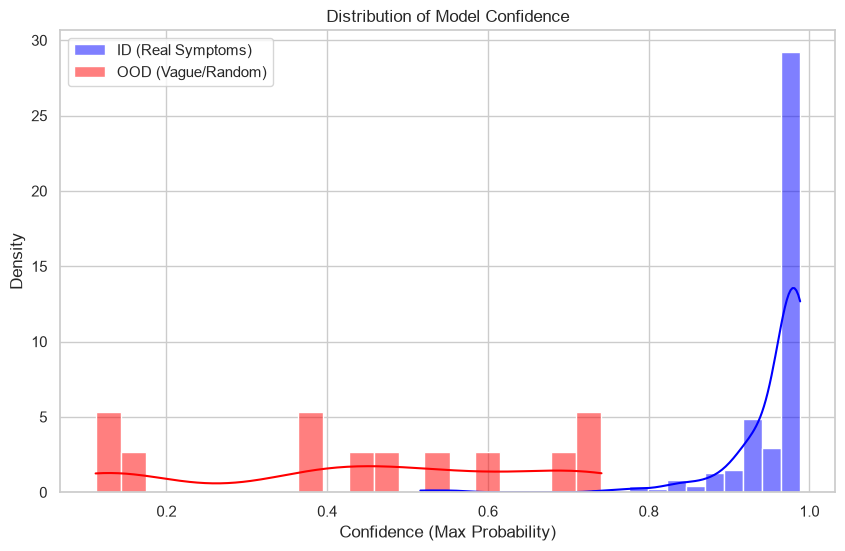

In [4]:
plt.figure(figsize=(10, 6))
sns.histplot(id_probs, color='blue', label='ID (Real Symptoms)', kde=True, stat='density', bins=20)
sns.histplot(ood_probs, color='red', label='OOD (Vague/Random)', kde=True, stat='density', bins=20)
plt.title('Distribution of Model Confidence')
plt.xlabel('Confidence (Max Probability)')
plt.ylabel('Density')
plt.legend()
plt.show()

### 4. ROC Curve & Optimal Threshold
We calculate the ROC curve and find the threshold that maximizes Youden's J statistic (True Positive Rate - False Positive Rate).

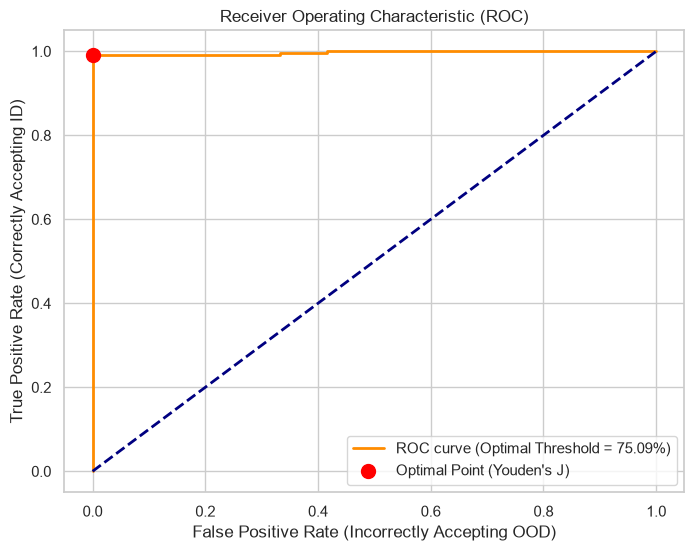

Optimal Confidence Threshold: 75.09%
Correctly accepted real symptoms (TPR): 99.00%
Incorrectly accepted vague text (FPR): 0.00%
Overall F1 Score: 0.9950


In [5]:
y_true = [1] * len(id_probs) + [0] * len(ood_probs)
y_scores = id_probs + ood_probs

fpr, tpr, thresholds = roc_curve(y_true, y_scores)
j_scores = tpr - fpr
best_idx = np.argmax(j_scores)
best_threshold = thresholds[best_idx]

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (Optimal Threshold = {best_threshold*100:.2f}%)')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.scatter(fpr[best_idx], tpr[best_idx], color='red', s=100, label='Optimal Point (Youden\'s J)', zorder=5)
plt.xlabel('False Positive Rate (Incorrectly Accepting OOD)')
plt.ylabel('True Positive Rate (Correctly Accepting ID)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc='lower right')
plt.show()

y_pred = [1 if score >= best_threshold else 0 for score in y_scores]
f1 = f1_score(y_true, y_pred)

print(f'Optimal Confidence Threshold: {best_threshold * 100:.2f}%')
print(f'Correctly accepted real symptoms (TPR): {tpr[best_idx]*100:.2f}%')
print(f'Incorrectly accepted vague text (FPR): {fpr[best_idx]*100:.2f}%')
print(f'Overall F1 Score: {f1:.4f}')